# Global Co2 Emissions Responsibility : Total vs Per-Capita vs Historical Accountability Dashboard

## Introduction
Brief overview of analysis purpose
This exploratory data analysis investigates global CO₂ emissions responsibility using total emissions, per-capita emissions, and cumulative historical contributions. The purpose of this analysis is to understand how responsibility for climate change differs between countries when viewed from different perspectives.

The analysis focuses on data from 1990 onwards to align with international climate policy baselines. Insights generated from this stage will inform the design of the interactive dashboard and support clear communication of fairness, accountability, and long-term emissions trends.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')  


In [4]:
# Loading the dataset
df_co2_emissions_clean = pd.read_csv('../DataSet/Cleaned/CO2_Emissions_Cleaned.csv')
# Displaying the first few rows of the dataset
df_co2_emissions_clean.head()


,country,iso_code,year,co2,co2_per_capita,gdp,population,cumulative_co2
0,Afghanistan,AFG,1990,2.024326,0.168054,1.306598e+10,12045664.0,58.603493
1,Afghanistan,AFG,1991,1.914301,0.156411,1.204736e+10,12238879.0,60.517792
2,Afghanistan,AFG,1992,1.482054,0.111609,1.267754e+10,13278983.0,61.999847
3,Afghanistan,AFG,1993,1.486943,0.099506,9.834582e+09,14943175.0,63.486794
4,Afghanistan,AFG,1994,1.453829,0.089462,7.919856e+09,16250800.0,64.940620


In [25]:
## Descriptive statistics of the dataset
df_co2_emissions_clean.describe()

,year,co2,co2_per_capita,gdp,population,cumulative_co2
count,7508.000000,7508.000000,7442.000000,5.409000e+03,7.442000e+03,7508.000000
mean,2007.035828,137.544464,5.022831,4.895098e+11,3.179892e+07,5822.072674
std,10.083330,675.286457,7.795041,1.705000e+12,1.262322e+08,27988.146188
min,1990.000000,0.000000,0.000000,2.571720e+08,1.776000e+03,0.000000
25%,1998.000000,0.852971,0.714055,1.886576e+10,7.567225e+05,23.068187
50%,2007.000000,7.172069,2.744757,6.111433e+10,5.713997e+06,227.102509
75%,2016.000000,53.937630,6.832723,2.910000e+11,2.045923e+07,1978.472718
max,2024.000000,12289.037110,364.790833,2.700000e+13,1.450936e+09,434866.562500


In [35]:
##Dataset information
df_co2_emissions_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7508 entries, 0 to 7507
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   country         7508 non-null   object 
 1   iso_code        7508 non-null   object 
 2   year            7508 non-null   int64  
 3   co2             7508 non-null   float64
 4   co2_per_capita  7442 non-null   float64
 5   gdp             5409 non-null   float64
 6   population      7442 non-null   float64
 7   cumulative_co2  7508 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 469.4+ KB


## Global Emissions Trends (H1 Validation)
This analysis examines whether global Co2 emissions have increased since 1990

In [36]:
# Validating the H1: "Global CO₂ emissions have increased significantly since 1990."
global_trend = df_co2_emissions_clean.groupby('year', as_index=False)['co2'].sum()
global_trend.head()



,year,co2
0,1990,22184.273978
1,1991,22662.921003
2,1992,21966.606838
3,1993,22192.437121
4,1994,22389.768557


\\talktalk\redirectedfolders\F.Afolabi\Documents\Global Co2 Emissions project 3\Global-Co2-Emissions-Responsibility\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


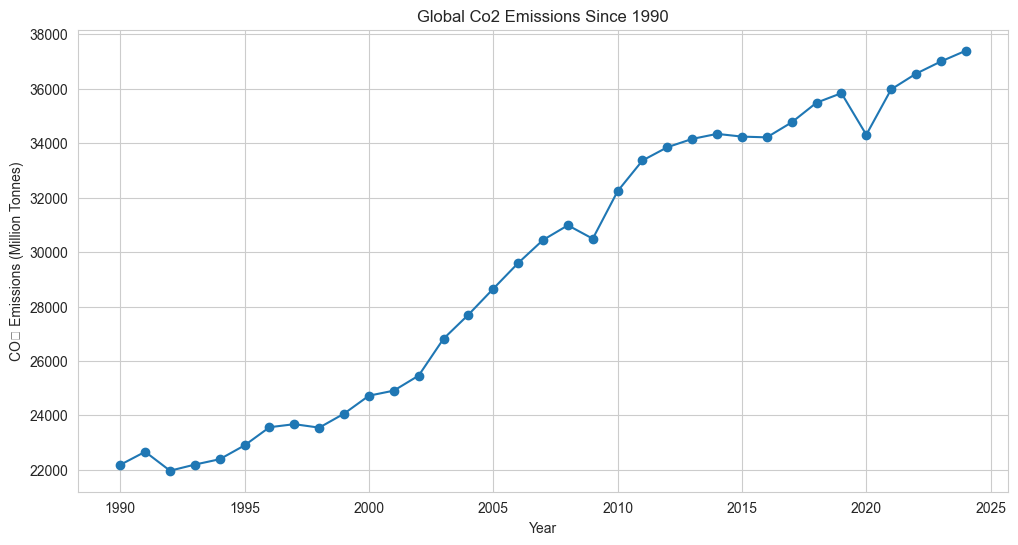

In [37]:
## Plotting the global CO₂ emissions trend over time
plt.figure(figsize=(12, 6))
plt.plot(global_trend['year'], global_trend['co2'], marker='o')
plt.title('Global Co2 Emissions Since 1990')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions (Million Tonnes)')
plt.grid(True)
plt.show()

## Interpretation
The graph shows a clear upward trend in global CO₂ emissions from 1990 to 2024. Emissions increased steadily throughout the 1990s and accelerated significantly during the early 2000s, reflecting rapid industrialisation and economic growth in emerging economies.

A period of slower growth  is visible between 2013 and 2016,where emissions appear to level off slightly before rising again, this could possibly be because of renewable adoption, efficiency improvements or economic slowdowns in some region. Followed by a sharp decline in 2020, likely linked to the global COVID-19 pandemic, reduced travel and reduced industrial activity. However, emissions rose quickly thereafter, reaching record highs by 2024.

Overall, the trend supports the hypothesis that global CO₂ emissions have increased significantly since 1990.

## Validating the H2: " Countries with large populations account for higher total emissions but do not necessarily rank highest in per-capita emissions."
## Top Emitting Countries.
This section identifies the countries with the highest total CO₂ emissions in the most recent reporting year and checks whether high-population countries tend to dominate total emissions.


In [38]:
# Validating H2: "High population countries are the largest contributors to global CO₂ emissions."
## Finding the latest year in the dataset
latest_year = df_co2_emissions_clean['year'].max()
latest_year

2024

In [39]:
## Filtering the dataset for the latest year
df_latest_year = df_co2_emissions_clean[df_co2_emissions_clean['year'] == latest_year].copy()
df_latest_year.head()


,country,iso_code,year,co2,co2_per_capita,gdp,population,cumulative_co2
34,Afghanistan,AFG,2024,10.825998,0.253848,NaN,42647502.0,242.635437
69,Albania,ALB,2024,4.444448,1.591990,NaN,2791756.0,307.938110
104,Algeria,DZA,2024,198.203186,4.233817,NaN,46814302.0,5476.567871
139,Andorra,AND,2024,0.424663,5.181661,NaN,81955.0,16.654968
174,Angola,AGO,2024,22.333584,0.589497,NaN,37885854.0,739.587707


In [40]:
## dispaying the shape of the filtered dataset
df_latest_year.shape

(215, 8)

In [41]:
## Creating the top 10 countries by CO₂ emissions for the latest year
top10_countries = df_latest_year.sort_values(by='co2', ascending=False).head(10)


In [42]:
## creating the top 10 total emitters table
top10_countries_table = top10_countries[['country', 'co2', 'co2_per_capita', 'population']]
top10_countries_table

,country,co2,co2_per_capita,population
1469,China,12289.037110,8.658390,1.419321e+09
7192,United States,4904.119629,14.197287,3.454266e+08
3172,India,3193.478027,2.200978,1.450936e+09
5582,Russia,1780.524414,12.294705,1.448204e+08
3452,Japan,961.867310,7.772474,1.237530e+08
3207,Indonesia,812.220215,2.865096,2.834879e+08
3242,Iran,792.631165,8.656227,9.156774e+07
5897,Saudi Arabia,692.133484,20.379194,3.396275e+07
6317,South Korea,583.679138,11.285893,5.171759e+07
2682,Germany,572.319153,6.768824,8.455223e+07


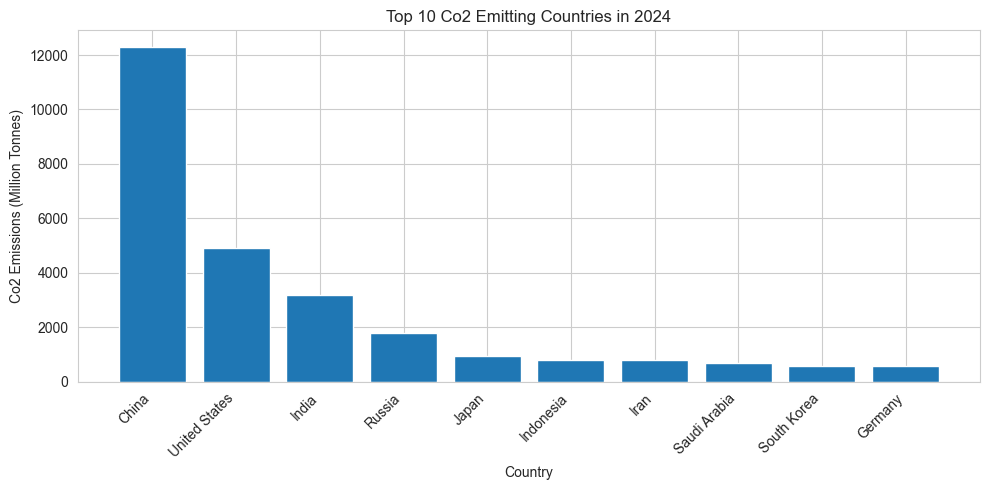

In [43]:
## Creating a Bar Chart for the top 10 CO₂ emitting countries
plt.figure(figsize=(10, 5))
plt.bar(top10_countries_table['country'], top10_countries_table['co2'])
plt.xlabel('Country')
plt.ylabel('Co2 Emissions (Million Tonnes)')
plt.title(f"Top 10 Co2 Emitting Countries in {latest_year}")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [44]:
## Validating if these top 10 countries are also the most populous
top10_countries.sort_values(by='population', ascending=False)[["country", "population", "co2"]]


,country,population,co2
3172,India,1.450936e+09,3193.478027
1469,China,1.419321e+09,12289.037110
7192,United States,3.454266e+08,4904.119629
3207,Indonesia,2.834879e+08,812.220215
5582,Russia,1.448204e+08,1780.524414
3452,Japan,1.237530e+08,961.867310
3242,Iran,9.156774e+07,792.631165
2682,Germany,8.455223e+07,572.319153
6317,South Korea,5.171759e+07,583.679138
5897,Saudi Arabia,3.396275e+07,692.133484



##
The Top 10 chart shows that a small number of countries contribute a large share of total CO₂ emissions in 2024. China is the highest emitter by a wide margin, followed by the United States and India.

When population is considered, several countries in the Top 10 also have very large populations (for example China, India, the United States, and Indonesia). This suggests that population size is one important reason why some countries have high total emissions. However, population alone does not explain everything, because countries with similar population sizes can still have very different total emissions.

This supports the first part of H2: large-population countries often account for higher total emissions.

## H2 Part B Total Emissions  Vs Per Capita Emissions
This visual analysis examines whether countries with high total emissions also rank highly in per-capita emissions.

In [45]:
# Removing Missing Values from the latest year dataset
df_latest_year_clean = df_latest_year.dropna(subset=['co2', 'co2_per_capita']).copy()
df_latest_year_clean.shape


(213, 8)

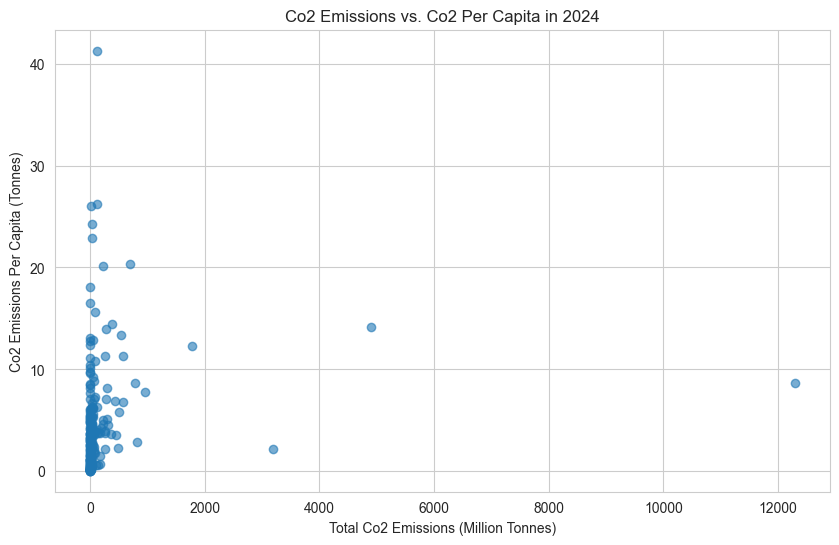

In [50]:
# Creating a scatter plot to visualize the relationship between population and CO₂ emissions for the latest year
plt.figure(figsize=(10, 6)) 
plt.scatter(df_latest_year_clean['co2'], df_latest_year_clean['co2_per_capita'], alpha=0.6)
plt.xlabel('Total Co2 Emissions (Million Tonnes)')
plt.ylabel('Co2 Emissions Per Capita (Tonnes)') 
plt.title(f'Co2 Emissions vs. Co2 Per Capita in {latest_year}')
plt.show()

## Interpretation
The scatter plot compares total CO₂ emissions with per-capita emissions for countries in 2024. Most countries are grouped in the lower-left area of the chart, showing that they have both low total emissions and low emissions per person, these countries are probably small economies, developing nations or low industrial output countries.

Highly populated countries such as China(12,000 total co2 emissions, < 10 per-capita) and India (3,000 total co2 emissions, 2 per-capita) appear far to the right of the chart, meaning they produce large amounts of total emissions. However, they sit lower on the per-capita scale, showing that their emissions per person are not among the highest. This indicates that large population size increases total emissions but does not automatically mean higher individual responsibility.

On the other hand, some countries such as Qatar, UAE, Kuwait,  with smaller populations appear higher on the per-capita axis even though their total emissions are lower. This shows that lifestyle, energy use, and industrial activity can lead to higher emissions per person.

Overall, the visual supports the hypothesis that countries with large populations produce higher total emissions but do not necessarily rank highest in per-capita 

## Hypothesis 3
Statement:  Developed countries tend to have higher CO₂ emissions per capita compared to developing countries.
Validation: This will be assessed through per-capita emission rankings and scatter plot comparisons.
This analysis examines whether developed countries tend to produce higher CO₂ emissions per person compared to developing countries.

In [52]:
# Per-Capits Ranking Table
top10_per_capita = df_latest_year_clean.dropna(subset=['co2_per_capita'])

# Sorting the dataset by co2_per_capita in descending order and selecting the top 10 countries      
top10_per_capita = top10_per_capita.sort_values(by='co2_per_capita', ascending=False).head(10)


In [53]:
# creating a table with only the country and co2_per_capita columns
top10_per_capita[['country', 'co2_per_capita']]

,country,co2_per_capita
5512,Qatar,41.271179
3627,Kuwait,26.247530
1084,Brunei,26.046202
559,Bahrain,24.270082
6842,Trinidad and Tobago,22.931944
5897,Saudi Arabia,20.379194
7122,United Arab Emirates,20.131075
4812,New Caledonia,18.064400
6107,Sint Maarten (Dutch part),16.546274
5127,Oman,15.651107


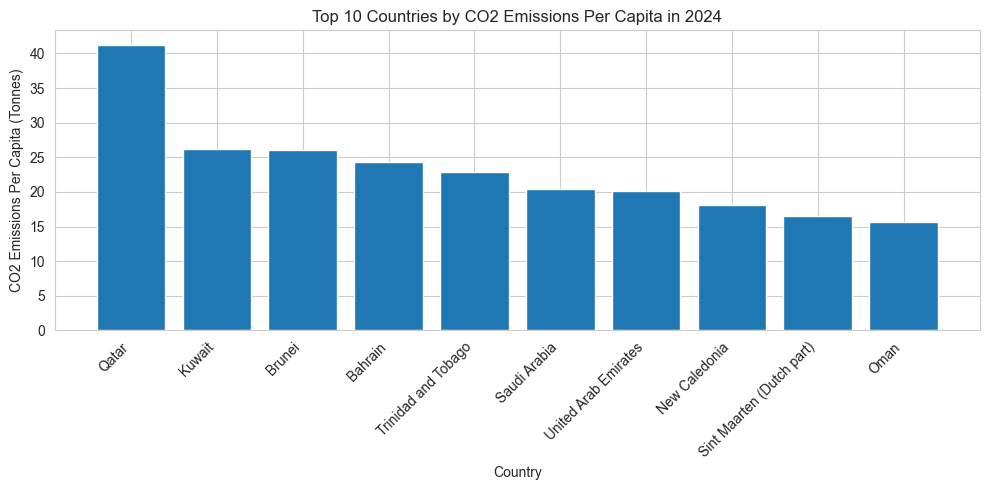

In [57]:
# Plotting a bar chart for the top 10 countries by Co2 emissions per capita
plt.figure(figsize=(10, 5))
plt.bar(top10_per_capita['country'], top10_per_capita['co2_per_capita'])
plt.xlabel('Country')
plt.ylabel('CO2 Emissions Per Capita (Tonnes)')
plt.title(f'Top 10 Countries by CO2 Emissions Per Capita in {latest_year}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Interpretation
The bar chart shows the countries with the highest CO₂ emissions per capita in 2024. Qatar ranks significantly higher than all other countries, followed by Kuwait, Brunei, and Bahrain.
Most of the countries in the Top 10 are high-income or oil-producing economies. Their energy-intensive industries and high consumption levels contribute to elevated emissions per person. Despite having smaller populations, these countries produce much higher emissions per individual.Their responsibility is industry driven rather than population driven.
In contrast, many developing countries with large populations such as India, Indonesia, Nigeria do not appear in the per-capita Top 10. This highlights the difference between total emissions and individual emissions responsibility.
Overall, this support the hypothesis that developed countries tend to have higher CO₂ emissions per capita compared to developing countries.